# IT25103995 — Samarakoon S. M. D. S.
## Individual Preprocessing Task: Outlier Detection and Removal
**Dataset:** Chronic Kidney Disease (UCI ML Repository, id 336)
**Group:** 2026-Y2-S1-KU-56

This notebook demonstrates my individually assigned preprocessing technique — **outlier detection and
treatment** — applied to the numeric clinical features of the CKD dataset (building on
`IT25103994_encoded.csv` from Amarathunge's notebook).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df = pd.read_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/IT25103995_outliers_treated.csv')
numeric_cols = ['age','bp','bgr','bu','sc','sod','pot','hemo','pcv','wbcc','rbcc']
df[numeric_cols].describe()

,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,390.000000,387.000000,355.000000,380.000000,382.000000,312.000000,311.000000,347.000000,328.000000,293.000000,268.000000
mean,51.423077,76.485788,148.152113,57.450526,3.078403,137.508013,4.630868,12.523343,38.862805,8399.658703,4.707090
std,17.150265,13.697384,79.363566,50.567265,5.747473,10.418992,3.198409,2.916220,8.995212,2947.421654,1.027226
min,2.000000,50.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,54.500000,80.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.600000,40.000000,8000.000000,4.800000
75%,64.000000,80.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


### Why this technique is needed for this dataset
Clinical lab measurements such as blood urea (`bu`), serum creatinine (`sc`) and white blood cell count
(`wbcc`) can have extreme values for patients with severe kidney failure or lab entry errors. Outliers of
this size can dominate distance-based or gradient-based algorithms (e.g. SVM, k-NN) and distort scaling.
They need to be identified and, where they look like implausible/extreme readings, treated.

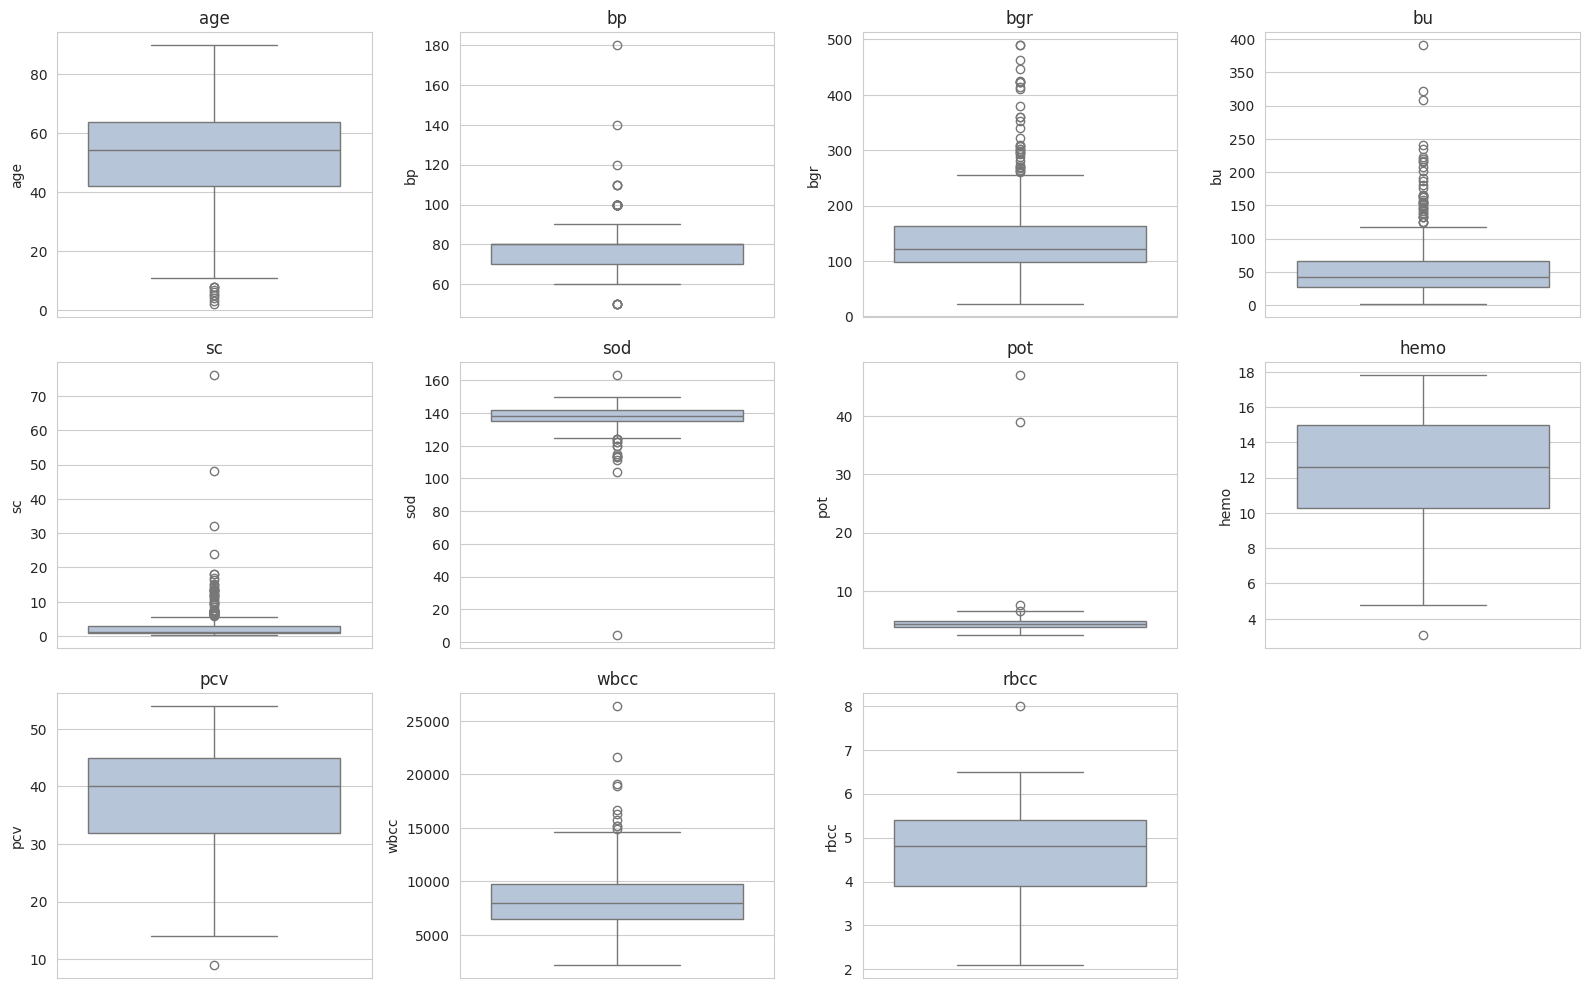

In [ ]:
# EDA Visualization 1: boxplots of all numeric features to visualize outliers
fig, axes = plt.subplots(3, 4, figsize=(16,10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightsteelblue')
    axes[i].set_title(col)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/IT25103995_boxplots_numeric_features.png', dpi=120)
plt.show()

**Interpretation:** `bu` (blood urea), `sc` (serum creatinine) and `wbcc` (white blood cell count) show
the most extreme outliers, with several points far beyond the upper whisker — clinically plausible for
late-stage CKD patients (urea and creatinine rise sharply as kidney function fails) but statistically extreme
relative to the rest of the sample.

In [ ]:
# IQR method: identify outliers per numeric column
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

outlier_report = {}
for col in numeric_cols:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_report[col] = n_out

pd.Series(outlier_report).sort_values(ascending=False)

,0
sc,51
bu,38
bp,36
bgr,34
sod,16
age,10
wbcc,10
pot,4
hemo,1
pcv,1


In [ ]:
# Cap (winsorize) outliers to the IQR bounds rather than deleting rows,
# since deleting would disproportionately remove genuine severe-CKD patients (a form of bias).
df_capped = df.copy()
for col in numeric_cols:
    lo, hi = iqr_bounds(df[col])
    df_capped[col] = df_capped[col].clip(lower=lo, upper=hi)

print("Rows before:", len(df), " Rows after (no rows dropped, values capped):", len(df_capped))

Rows before: 399  Rows after (no rows dropped, values capped): 399


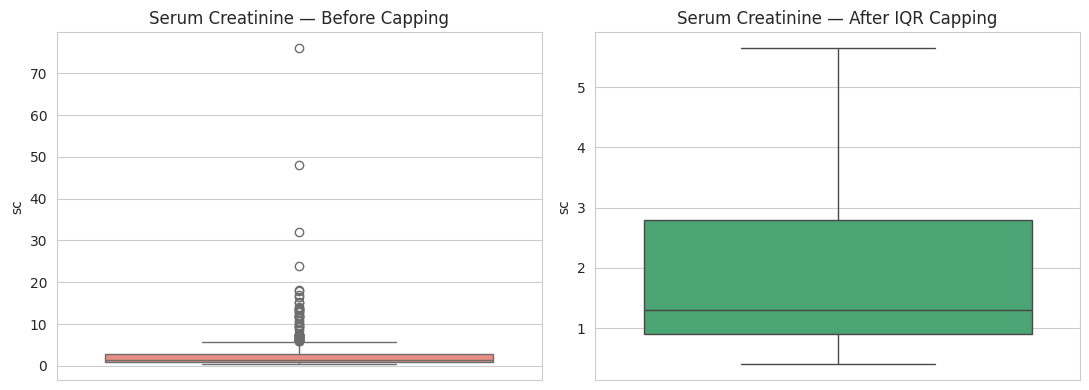

In [ ]:
# EDA Visualization 2: before vs after capping for the most affected column (sc - serum creatinine)
fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.boxplot(y=df['sc'], ax=axes[0], color='salmon')
axes[0].set_title('Serum Creatinine — Before Capping')
sns.boxplot(y=df_capped['sc'], ax=axes[1], color='mediumseagreen')
axes[1].set_title('Serum Creatinine — After IQR Capping')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/IT25103995_sc_before_after_capping.png', dpi=120)
plt.show()

**Interpretation:** Capping compresses the extreme creatinine values into a realistic range while
still keeping every one of the 399 records (unlike row deletion, which would have removed a meaningful
fraction of the severe-CKD group and biased the class balance).

In [ ]:
df_capped.to_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/IT25103995_outliers_treated.csv', index=False)
print("Saved outlier-treated dataset for downstream use by the group pipeline.")

Saved outlier-treated dataset for downstream use by the group pipeline.


### Summary
- **Technique:** Outlier detection using the IQR (Interquartile Range) rule, treated via **capping /
  winsorizing** rather than deletion.
- **Justification:** Row deletion on a dataset of only 399 records would have disproportionately removed
  genuine severe-CKD cases (creating bias), so capping preserves sample size while limiting the influence of
  extreme values on later scaling and model training.
- **Output:** `results/outputs/IT25103995_outliers_treated.csv` — same 399 rows, extreme numeric values capped.